In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import wilcoxon

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1257933019" 
# tab_gid = '908803302'
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:20, :]
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.00
1,pythia-70M,8-bit,41.39
2,pythia-70M,4-bit,39.21
3,pythia-70M,dyn,35.99
4,pythia-160M,Original,42.49
5,pythia-160M,8-bit,42.31
6,pythia-160M,4-bit,40.60
7,pythia-160M,dyn,38.07
8,pythia-410M,Original,43.51
9,pythia-410M,8-bit,43.61


/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_88264/550377877.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "4-bit": "Static (4-bit)", "dyn": "Dynamic (8-bit)"})


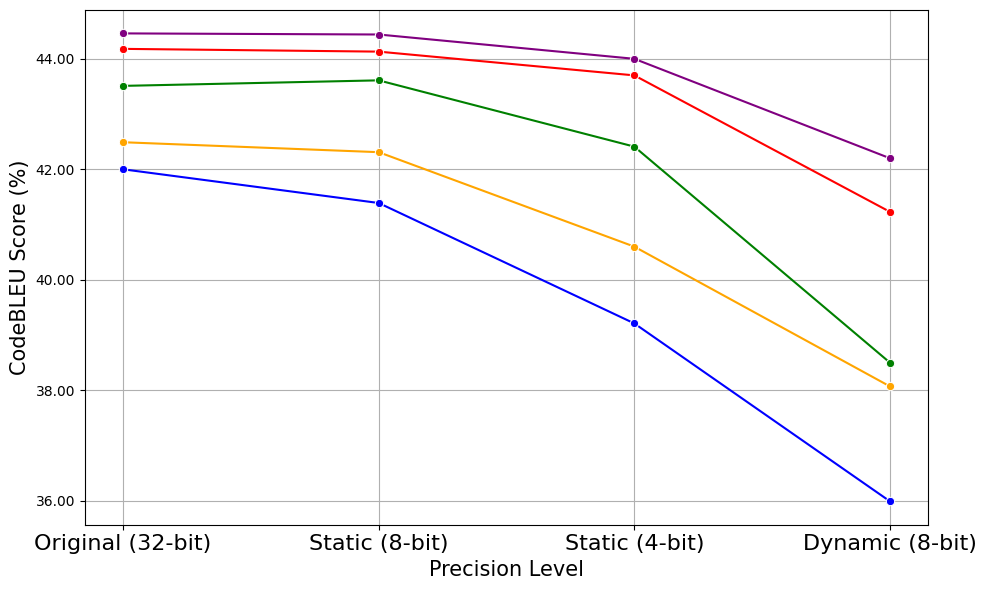

In [30]:
model_colors = {
    "pythia-70M": "blue",
    "pythia-160M": "orange",
    "pythia-410M": "green",
    "pythia-1B": "red",
    "pythia-1.4B": "purple"
}
compression_order = ["Original", "8-bit", "4-bit", "dyn"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# x axis labels names rename
df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "4-bit": "Static (4-bit)", "dyn": "Dynamic (8-bit)"})

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o", palette=model_colors, legend=False)

plt.ylabel("CodeBLEU Score (%)", fontsize=15)
plt.xlabel("Precision Level", fontsize=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
plt.xticks(fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.savefig("./output/staticVSdynamic.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_88264/2754322750.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Compression"] = df["Compression"].replace({


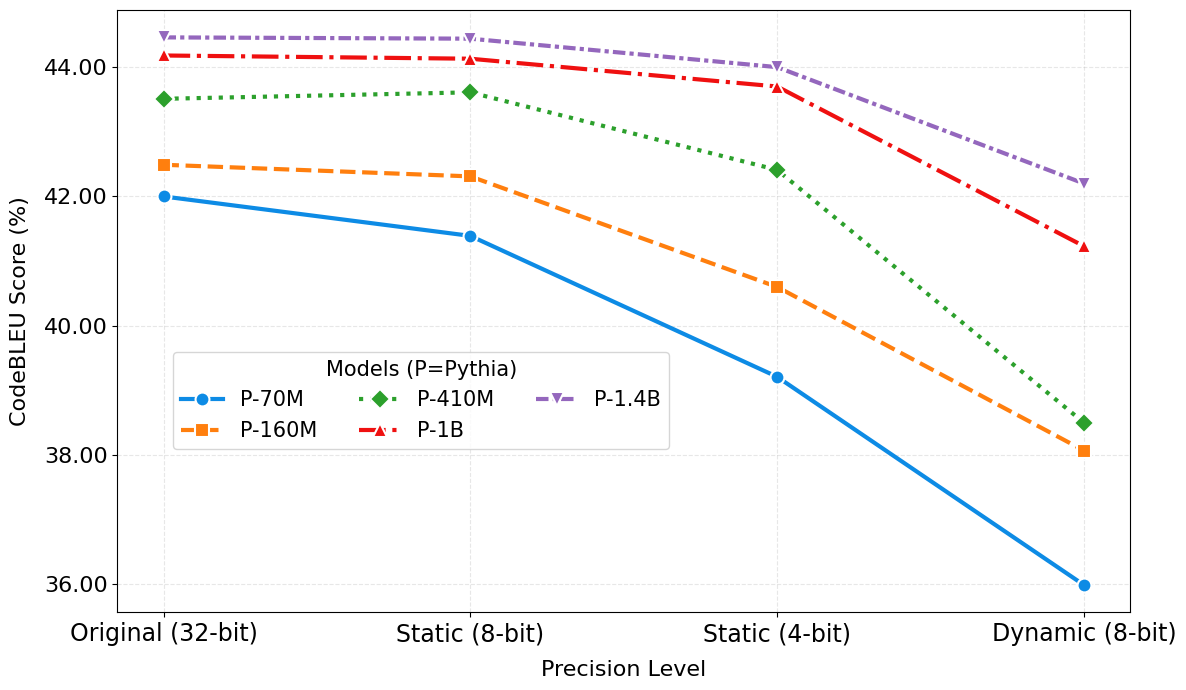

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:20, :]
# Define styles with line patterns
# model_styles = {
#     "pythia-70M": {"color": "blue", "marker": "o", "linestyle": "-", "linewidth": 3},
#     "pythia-160M": {"color": "orange", "marker": "s", "linestyle": "--", "linewidth": 3},
#     "pythia-410M": {"color": "green", "marker": "D", "linestyle": ":", "linewidth": 3},
#     "pythia-1B": {"color": "red", "marker": "^", "linestyle": "-.", "linewidth": 3},
#     "pythia-1.4B": {"color": "purple", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "linewidth": 3}
# }
model_styles = {
        "pythia-70M": {"color": "#0d8be5", "marker": "o", "linestyle": "-", "dash": None, "label": "P-70M"},
        "pythia-160M": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-160M"},
        "pythia-410M": {"color": "#2ca02c", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-410M"},
        "pythia-1B": {"color": "#ef1010", "marker": "^", "linestyle": "-.", "dash": (3, 5, 1, 5), "label": "P-1B"},
        "pythia-1.4B": {"color": "#9467bd", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "dash": None, "label": "P-1.4B"}
    }
# Prepare data
compression_order = ["Original", "8-bit", "4-bit", "dyn"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Rename x-axis labels
df["Compression"] = df["Compression"].replace({
    "Original": "Original (32-bit)", 
    "8-bit": "Static (8-bit)", 
    "4-bit": "Static (4-bit)", 
    "dyn": "Dynamic (8-bit)"
})

# Create figure
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Plot each model with custom styling
for model, style in model_styles.items():
    if model in df["Model"].unique():
        model_df = df[df["Model"] == model]
        ax.plot(
            model_df["Compression"].cat.codes,  # Use numeric codes for positioning
            model_df["BLEU"],
            label=model.replace("pythia-", "P-"),
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=3,
            markersize=10,
            markeredgecolor='white',
            markeredgewidth=1.5
        )

# Configure x-axis
ax.set_xticks(range(len(compression_order)))
ax.set_xticklabels([
    "Original (32-bit)", 
    "Static (8-bit)", 
    "Static (4-bit)", 
    "Dynamic (8-bit)"
], fontsize=17, rotation=0, ha='center')

# Add legend
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.3, .45),
    ncol=3,
    fontsize=15,
    frameon=True,
    title='Models (P=Pythia)',
    title_fontsize=15
)

# Axis labels and formatting
plt.ylabel("CodeBLEU Score (%)", fontsize=16, labelpad=10)
plt.xlabel("Precision Level", fontsize=16, labelpad=10)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Final adjustments
plt.tight_layout()
plt.savefig("./output/staticVSdynamic.pdf", dpi=350, bbox_inches="tight")
plt.show()

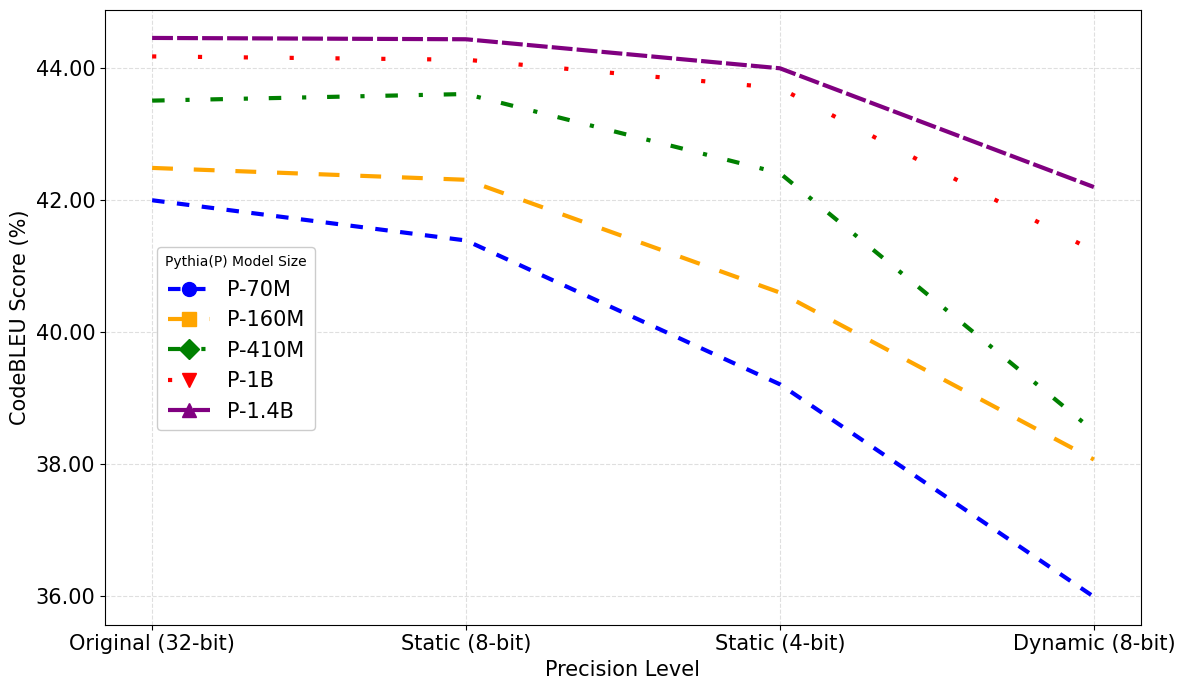

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:20, :]
df
# Define styles
model_colors = {
    "pythia-70M": "blue",
    "pythia-160M": "orange",
    "pythia-410M": "green",
    "pythia-1B": "red",
    "pythia-1.4B": "purple"
}

# Prepare compression categories
compression_map = {
    "Original": "Original (32-bit)",
    "8-bit": "Static (8-bit)",
    "4-bit": "Static (4-bit)", 
    "dyn": "Dynamic (8-bit)"
}
df["Compression"] = df["Compression"].map(compression_map)
df["Compression"] = pd.Categorical(df["Compression"], categories=list(compression_map.values()), ordered=True)

# Create figure
plt.figure(figsize=(12, 7))

# First create the basic lineplot without styles
ax = sns.lineplot(
    data=df, 
    x="Compression", 
    y="BLEU", 
    hue="Model",
    markers=["o", "s", "D", "v", "^"],
    markersize=10,
    linewidth=2,  # Start with default width
    palette=model_colors,
    legend=False
)

# MANUALLY apply line styles to each path
for i, line in enumerate(ax.lines):
    model = df["Model"].unique()[i]
    if model == "pythia-70M":
        line.set_linestyle((0, (3, 3)))  # Dotted
    elif model == "pythia-160M":
        line.set_linestyle((0, (5, 5)))  # Dashed
    elif model == "pythia-410M":
        line.set_linestyle((0, (3, 5, 1, 5)))  # Dash-dot
    elif model == "pythia-1B":
        line.set_linestyle((0, (1, 10)))  # Loosely dashed
    elif model == "pythia-1.4B":
        line.set_linestyle((0, (5, 1)))  # Densely dashed
    line.set_linewidth(3)  # Make lines thicker

# Create custom legend
markers = ["o", "s", "D", "v", "^"]
line_styles = [
    (0, (3, 3)),  # pythia-70M
    (0, (5, 5)),   # pythia-160M
    (0, (3, 5, 1, 5)),  # pythia-410M
    (0, (1, 10)),  # pythia-1B
    (0, (5, 1))    # pythia-1.4B
]

legend_elements = [
    Line2D([0], [0], 
           color=model_colors[model],
           linestyle=line_styles[i],
           lw=3,
           marker=markers[i],
           markersize=10,
           label=model.replace("pythia-", "P-"))
    for i, model in enumerate(model_colors.keys())
]

plt.legend(
    handles=legend_elements,
    title='Pythia(P) Model Size',
    bbox_to_anchor=(0.04, 0.3),
    loc='lower left',
    framealpha=1,
    fontsize=15
)

# Formatting
plt.ylabel("CodeBLEU Score (%)", fontsize=15)
plt.xlabel("Precision Level", fontsize=15)
plt.xticks(rotation=0, ha='center', fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.tight_layout()
plt.savefig("output/staticVSdynamic.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_88264/1366845036.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "dyn": "Dynamic (8-bit)", "4-bit": "Dynamic (4-bit)"})


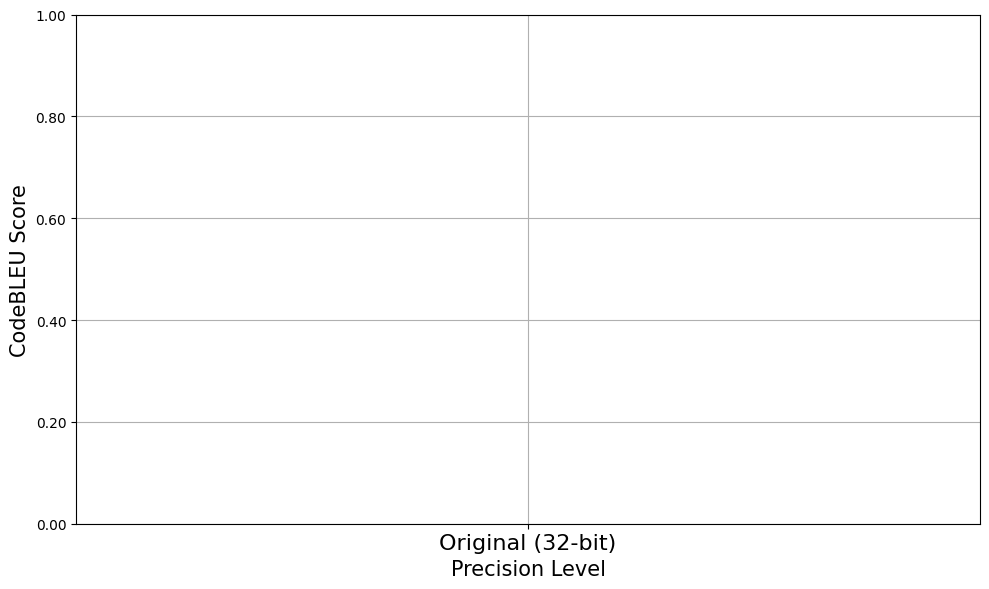

In [28]:
model_colors = {
    "pythia-70M": "blue",
    "pythia-160M": "orange",
    "pythia-410M": "green",
    "pythia-1B": "red",
    "pythia-1.4B": "purple"
}
compression_order = ["Original", "8-bit", "dyn", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# x axis labels names rename
df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "dyn": "Dynamic (8-bit)", "4-bit": "Dynamic (4-bit)"})

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o", palette=model_colors, legend=False)

plt.ylabel("CodeBLEU Score", fontsize=15)
plt.xlabel("Precision Level", fontsize=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
plt.xticks(fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.savefig("./output/prelim-1.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
def check_significance(df, col1, col2):
    stat, p_value = wilcoxon(df[col1], df[col2], alternative='greater')
    if p_value < 0.05:
        print(f"({col1} vs {col2}): {stat}, p-value: {p_value} \033[92mThe difference is statistically significant.\033[0m")
    else:
        print(f"({col1} vs {col2}): {stat}, p-value: {p_value} \033[91mThe difference is NOT statistically significant.\033[0m")

In [26]:
limit = 20 #15 39
df0 = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:limit, :]
df1 = df0.pivot(index="Model", columns="Compression", values="BLEU")
df = df1.reset_index()
print(df.shape)
check_significance(df, "Original", "8-bit")
check_significance(df, "Original", "dyn")

(5, 5)
(Original vs 8-bit): 12.0, p-value: 0.15625 The difference is NOT statistically significant.
(Original vs dyn): 15.0, p-value: 0.03125 The difference is statistically significant.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1257933019"
# tab_gid = "1990888583" 
limit = 20
leftCol = "ROC_AUC"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=['Model', 'Compression', leftCol, 'BLEU']).iloc[:limit, :]
df

,Model,Compression,BLEU,ROC_AUC
0,pythia-70M,Original,42.00,64.55
1,pythia-70M,8-bit,41.39,64.53
2,pythia-70M,4-bit,39.21,63.36
3,pythia-70M,dyn,35.99,56.73
4,pythia-160M,Original,42.49,65.70
5,pythia-160M,8-bit,42.31,65.66
6,pythia-160M,4-bit,40.60,64.50
7,pythia-160M,dyn,38.07,55.04
8,pythia-410M,Original,43.51,67.41
9,pythia-410M,8-bit,43.61,67.40


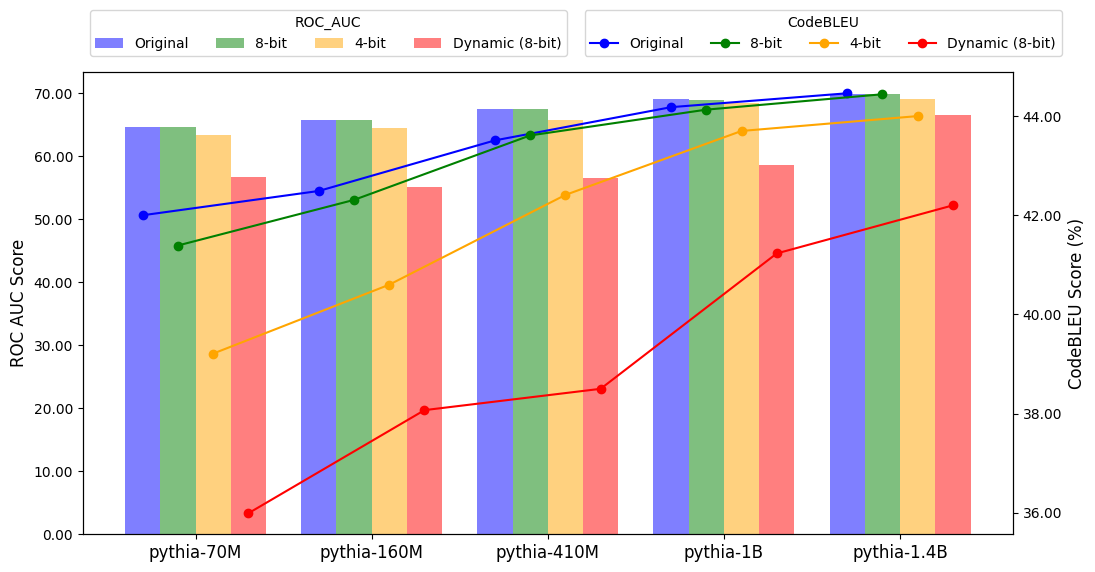

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1257933019"
# tab_gid = "1990888583" 
limit = 20
leftCol = "Size (MB)"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=['Model', 'Compression', leftCol, 'BLEU']).iloc[:limit, :]
df

,Model,Compression,Size (MB),BLEU
0,pythia-70M,Original,281.73,42.00
1,pythia-70M,8-bit,122.13,41.39
2,pythia-70M,4-bit,113.77,39.21
3,pythia-70M,dyn,147.86,35.99
4,pythia-160M,Original,649.34,42.49
5,pythia-160M,8-bit,240.12,42.31
6,pythia-160M,4-bit,202.65,40.60
7,pythia-160M,dyn,278.67,38.07
8,pythia-410M,Original,1621.43,43.51
9,pythia-410M,8-bit,509.70,43.61


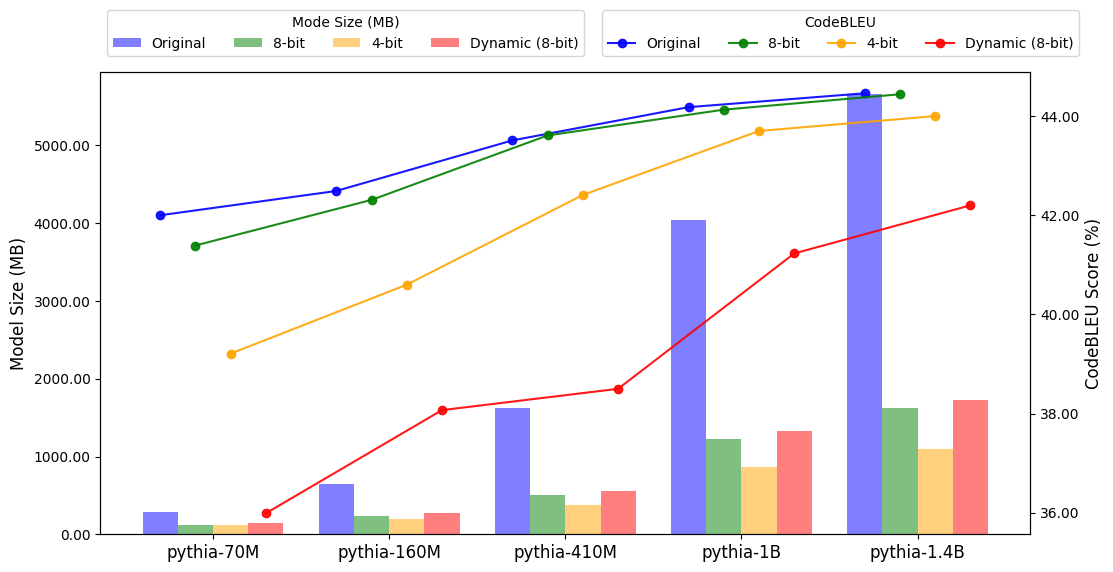

In [30]:

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()
# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange", "red"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset[leftCol], width=bar_width, label=f"{comp}", alpha=0.5, color=colors[i])

ax1.set_ylabel("Model Size (MB)", fontsize=12)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=0, fontsize=12)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1.15), title="Mode Size (MB)", ncol=len(ax1.get_legend_handles_labels()[0]))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
ax1.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")

# Second y-axis for performance scores
ax2 = ax1.twinx()
# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp}", color=colors[i], alpha=0.9)

ax2.set_ylabel("CodeBLEU Score (%)", fontsize=12)
ax2.legend(
    loc='upper right',
    bbox_to_anchor=(1.06, 1.15),
    title="CodeBLEU",
    ncol=len(ax2.get_legend_handles_labels()[0])
)
ax2.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.savefig(f"./output/modelSizevsTask.png", dpi=300, bbox_inches="tight")
plt.show()